# Multi-reference stain normalization investigation

This notebook investigates whether using **multiple reference patches** improves stain normalization robustness compared with one reference.

## What this does
- Build stain/tissue features from a train sample.
- Cluster patches into a few modes.
- Pick one high-quality reference per cluster.
- Compare single-reference vs multi-reference on an evaluation sample.
- Show quantitative metrics + visual examples.

> Investigatory only: no dataset overwrite.

In [1]:
import os
import sys
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from staintools import StainNormalizer, ReinhardColorNormalizer
from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer

RNG = np.random.RandomState(42)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_ROOT, "pcam_data")
TRAIN_X_PATH = os.path.join(DATA_DIR, "training", "camelyonpatch_level_2_split_train_x.h5")
TEST_X_PATH = os.path.join(DATA_DIR, "test", "camelyonpatch_level_2_split_test_x.h5")
REF_CFG_PATH = os.path.join(PROJECT_ROOT, "experiments", "stain_reference", "stain_reference.json")

for p in [TRAIN_X_PATH, TEST_X_PATH]:
    if not os.path.isfile(p):
        raise FileNotFoundError(p)

print("Project root:", PROJECT_ROOT)
print("Train:", TRAIN_X_PATH)
print("Test:", TEST_X_PATH)

Project root: c:\GP_ECG
Train: c:\GP_ECG\pcam_data\training\camelyonpatch_level_2_split_train_x.h5
Test: c:\GP_ECG\pcam_data\test\camelyonpatch_level_2_split_test_x.h5


In [2]:
# Parameters
N_TRAIN_FEATURE_SAMPLE = 20000
N_EVAL_SAMPLE = 3000
N_CLUSTERS = 4

# Quality-related thresholds (aligned with preprocessing script)
SOLID_COLOR_STD = 0.04
HIGH_BLACK_RATIO = 0.5
LOW_TISSUE_THRESHOLD = 0.35
SAT_THRESHOLD = 0.12
VAR_THRESHOLD = 0.003
EDGE_LO, EDGE_HI = 0.12, 0.45
LOCAL_VAR_WIN = 11

# Decision rule percentile
BLUE_DOM_PERCENTILE = 25.0

print("N_TRAIN_FEATURE_SAMPLE:", N_TRAIN_FEATURE_SAMPLE)
print("N_EVAL_SAMPLE:", N_EVAL_SAMPLE)
print("N_CLUSTERS:", N_CLUSTERS)

N_TRAIN_FEATURE_SAMPLE: 20000
N_EVAL_SAMPLE: 3000
N_CLUSTERS: 4


In [3]:
def to_01(p):
    p = np.asarray(p)
    return np.clip(p.astype(np.float64) / 255.0, 0, 1) if p.max() > 1 else np.clip(p.astype(np.float64), 0, 1)

def to_uint8(p):
    p = np.asarray(p)
    if p.max() > 1:
        return np.clip(p, 0, 255).astype(np.uint8)
    return (np.clip(p, 0, 1) * 255).astype(np.uint8)

def otsu_threshold_01(gray):
    flat = np.asarray(gray).ravel().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 1))
    bin_centers = (np.arange(256) + 0.5) / 256.0
    total = hist.sum()
    if total == 0:
        return 0.5
    p = hist / total
    sigma_b_sq_max, best_t = -1.0, 0.5
    for t in range(1, 255):
        w0, w1 = p[:t].sum(), p[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (p[:t] * bin_centers[:t]).sum() / w0
        mu1 = (p[t:] * bin_centers[t:]).sum() / w1
        sigma = w0 * w1 * (mu0 - mu1) ** 2
        if sigma > sigma_b_sq_max:
            sigma_b_sq_max = sigma
            best_t = bin_centers[t]
    return best_t

def saturation_from_rgb(rgb01):
    mx, mn = rgb01.max(axis=2), rgb01.min(axis=2)
    return np.where(mx > 1e-8, (mx - mn) / np.maximum(mx, 1e-8), 0.0)

def tissue_pct_final(p01):
    gray = np.clip(p01.mean(axis=2).astype(np.float64), 0, 1)
    n = gray.size
    sat = saturation_from_rgb(p01)
    var_map = uniform_filter(gray ** 2, size=LOCAL_VAR_WIN, mode="nearest") - uniform_filter(gray, size=LOCAL_VAR_WIN, mode="nearest") ** 2
    mix = ((sat > SAT_THRESHOLD) | (var_map > VAR_THRESHOLD)).mean()
    if EDGE_LO <= mix <= EDGE_HI:
        p5, p95 = np.percentile(gray, 5), np.percentile(gray, 95)
        span = max(p95 - p5, 1e-8)
        g = np.clip((gray - p5) / span, 0, 1)
        t = otsu_threshold_01(g)
        otsu_norm = float(np.sum(g < t) / n)
        return float(max(mix, otsu_norm))
    return float(mix)

def passes_quality(p01):
    gray = p01.mean(axis=2)
    gray_std = float(np.std(gray))
    if gray_std < SOLID_COLOR_STD:
        return False
    black_ratio = float(np.sum(p01 <= 0.1) / p01.size)
    if black_ratio >= HIGH_BLACK_RATIO:
        return False
    if tissue_pct_final(p01) < LOW_TISSUE_THRESHOLD:
        return False
    return True

def patch_features(p01):
    m = p01.mean(axis=(0, 1))
    tissue = tissue_pct_final(p01)
    blue_dom = float((p01[:, :, 2] > p01[:, :, 0]).mean())
    pink_pct = float((p01[:, :, 0] > p01[:, :, 2]).mean())
    mean_sat = float(saturation_from_rgb(p01).mean())
    return {
        "tissue": tissue,
        "mean_r": float(m[0]),
        "mean_g": float(m[1]),
        "mean_b": float(m[2]),
        "blue_dom": blue_dom,
        "pink_pct": pink_pct,
        "mean_sat": mean_sat,
    }


In [4]:
# Sample train patches and compute features
with h5py.File(TRAIN_X_PATH, "r") as f:
    n_train = f["x"].shape[0]

n_take = min(N_TRAIN_FEATURE_SAMPLE, n_train)
train_idx = np.sort(RNG.choice(n_train, size=n_take, replace=False))

rows = []
with h5py.File(TRAIN_X_PATH, "r") as f:
    x = f["x"]
    for idx in train_idx:
        p01 = to_01(np.array(x[idx]))
        feats = patch_features(p01)
        feats["idx"] = int(idx)
        feats["pass_quality"] = bool(passes_quality(p01))
        rows.append(feats)

print("Feature rows:", len(rows))
print("Pass quality:", int(sum(r['pass_quality'] for r in rows)), "/", len(rows))

Feature rows: 20000
Pass quality: 19075 / 20000


In [5]:
# Cluster on quality-passed subset
good = [r for r in rows if r["pass_quality"]]
if len(good) < N_CLUSTERS:
    raise RuntimeError("Not enough quality-passed samples for clustering.")

feat_names = ["tissue", "mean_r", "mean_g", "mean_b", "blue_dom", "pink_pct", "mean_sat"]
X = np.array([[r[k] for k in feat_names] for r in good], dtype=np.float64)
idx_good = np.array([r["idx"] for r in good], dtype=np.int64)

scaler = StandardScaler()
Xz = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
cluster_id = kmeans.fit_predict(Xz)

print("Cluster sizes:")
for c in range(N_CLUSTERS):
    print(f"  cluster {c}: {(cluster_id == c).sum()}")

Cluster sizes:
  cluster 0: 4979
  cluster 1: 2909
  cluster 2: 5985
  cluster 3: 5202


In [6]:
# Pick one medoid-like reference per cluster (closest point to centroid in z-space)
ref_indices_multi = []
ref_features_multi = []
for c in range(N_CLUSTERS):
    mask = (cluster_id == c)
    Xc = Xz[mask]
    Ic = idx_good[mask]
    center = kmeans.cluster_centers_[c]
    d = np.sum((Xc - center) ** 2, axis=1)
    j = int(np.argmin(d))
    ref_indices_multi.append(int(Ic[j]))
    ref_features_multi.append(X[mask][j])

print("Multi-reference indices:", ref_indices_multi)

# Single reference from config (fallback: median-like from quality subset)
if os.path.isfile(REF_CFG_PATH):
    with open(REF_CFG_PATH, "r") as f:
        cfg = json.load(f)
    ref_idx_single = int(cfg.get("reference_train_index", ref_indices_multi[0]))
else:
    # choose median-like from quality subset
    target = np.median(X, axis=0)
    d = np.sum((X - target) ** 2, axis=1)
    ref_idx_single = int(idx_good[np.argmin(d)])

print("Single-reference index:", ref_idx_single)

Multi-reference indices: [237219, 240880, 162772, 137467]
Single-reference index: 89340


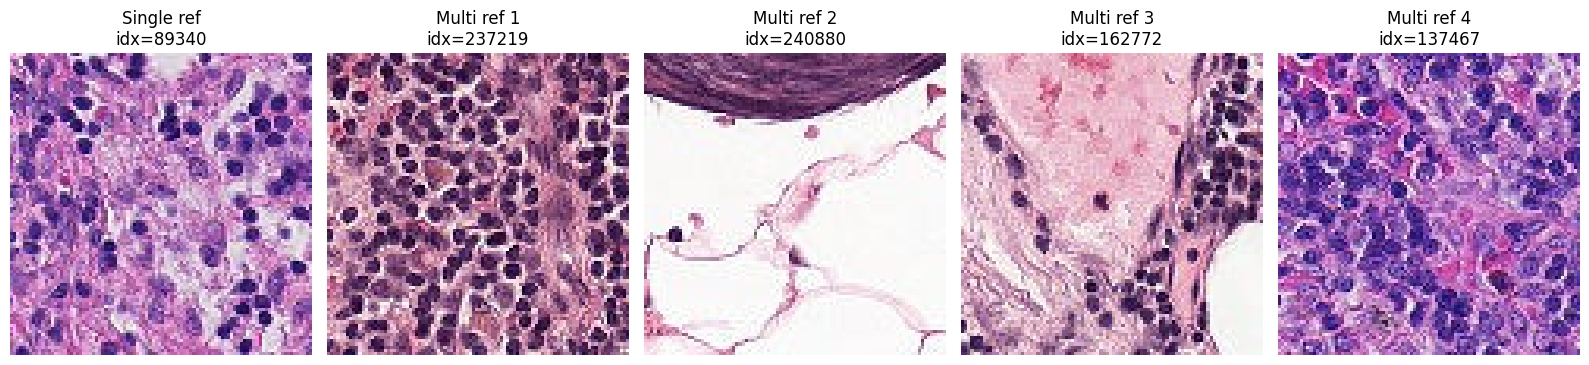

In [7]:
# Show all picked reference images (multi + single)
with h5py.File(TRAIN_X_PATH, "r") as f:
    x = f["x"]
    refs_multi = [to_01(np.array(x[idx])) for idx in ref_indices_multi]
    ref_single = to_01(np.array(x[ref_idx_single]))

n_multi = len(ref_indices_multi)
fig, axes = plt.subplots(1, n_multi + 1, figsize=(3.2 * (n_multi + 1), 3.6))
if n_multi + 1 == 1:
    axes = [axes]

# Single reference first
axes[0].imshow(ref_single)
axes[0].set_title(f"Single ref\nidx={ref_idx_single}")
axes[0].axis("off")

# Multi references
for j, (idx, img) in enumerate(zip(ref_indices_multi, refs_multi), start=1):
    axes[j].imshow(img)
    axes[j].set_title(f"Multi ref {j}\nidx={idx}")
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Fit normalizers for single and each multi-reference
lum_std = LuminosityStandardizer()

def fit_normalizers_for_ref(ref_idx):
    with h5py.File(TRAIN_X_PATH, "r") as f:
        ref_patch = np.array(f["x"][ref_idx])
    ref_u8 = to_uint8(ref_patch)
    ref_fit = LuminosityStandardizer.standardize(ref_u8.copy())

    mac = StainNormalizer(method="macenko")
    mac.fit(ref_fit)

    rei = ReinhardColorNormalizer()
    rei.fit(ref_u8)

    ref_01 = to_01(ref_patch)
    ref_mean = ref_01.mean(axis=(0, 1)).astype(np.float64)
    return {"idx": ref_idx, "macenko": mac, "reinhard": rei, "ref_mean": ref_mean}

single_pack = fit_normalizers_for_ref(ref_idx_single)
multi_packs = [fit_normalizers_for_ref(i) for i in ref_indices_multi]
print("Fitted single +", len(multi_packs), "multi-reference packs")

Fitted single + 4 multi-reference packs


In [10]:
def normalize_with_pack(p01, pack, blue_dom_threshold):
    pu8 = to_uint8(p01)
    try:
        pstd = lum_std.standardize(pu8)
    except Exception:
        pstd = pu8

    blue_dom = float((p01[:, :, 2] > p01[:, :, 0]).mean())
    use_reinhard = blue_dom < blue_dom_threshold

    mode = "lum"
    try:
        out_u8 = pack["reinhard"].transform(pstd) if use_reinhard else pack["macenko"].transform(pstd)
        mode = "rei" if use_reinhard else "mac"
    except Exception:
        try:
            out_u8 = pack["macenko"].transform(pstd) if use_reinhard else pack["reinhard"].transform(pstd)
            mode = "mac_fb" if use_reinhard else "rei_fb"
        except Exception:
            out_u8 = pstd
            mode = "lum"

    out = np.clip(out_u8.astype(np.float32) / 255.0, 0, 1)
    return out, mode

def pick_pack_multi(p01, packs):
    # choose nearest reference by mean RGB distance
    m = p01.mean(axis=(0, 1)).astype(np.float64)
    d = [float(np.abs(m - p["ref_mean"]).sum()) for p in packs]
    j = int(np.argmin(d))
    return packs[j], j

In [11]:
# Build evaluation sample from test split
with h5py.File(TEST_X_PATH, "r") as f:
    n_test = f["x"].shape[0]

n_eval = min(N_EVAL_SAMPLE, n_test)
eval_idx = np.sort(RNG.choice(n_test, size=n_eval, replace=False))

blue_vals = []
with h5py.File(TEST_X_PATH, "r") as f:
    x = f["x"]
    for i in eval_idx:
        p01 = to_01(np.array(x[i]))
        blue_vals.append(float((p01[:, :, 2] > p01[:, :, 0]).mean()))

blue_thr_eval = float(np.percentile(blue_vals, BLUE_DOM_PERCENTILE))
print(f"Eval blue_dom threshold ({BLUE_DOM_PERCENTILE:.1f}th pct): {blue_thr_eval:.4f}")

Eval blue_dom threshold (25.0th pct): 0.0960


In [ ]:
# Evaluate single vs multi reference
def summarize_result(name, records):
    arr_dist_before = np.array([r["dist_before"] for r in records], dtype=np.float64)
    arr_dist_after = np.array([r["dist_after"] for r in records], dtype=np.float64)
    arr_mean_r = np.array([r["mean_r_after"] for r in records], dtype=np.float64)
    arr_pink = np.array([r["pink_after"] for r in records], dtype=np.float64)
    arr_mean_b = np.array([r["mean_b_after"] for r in records], dtype=np.float64)
    modes = [r["mode"] for r in records]
    unique, counts = np.unique(modes, return_counts=True)
    mode_counts = {u: int(c) for u, c in zip(unique, counts)}

    purple_rate = float(np.mean((arr_mean_r < 0.2) | (arr_pink < 0.05)))
    outlier_rate = float(np.mean((arr_mean_r < 0.2) | (arr_mean_r > 0.8) | (arr_mean_b < 0.2) | (arr_mean_b > 0.8)))

    return {
        "name": name,
        "n": len(records),
        "dist_before": float(arr_dist_before.mean()),
        "dist_after": float(arr_dist_after.mean()),
        "delta_dist": float(arr_dist_after.mean() - arr_dist_before.mean()),
        "purple_rate": purple_rate,
        "outlier_rate": outlier_rate,
        "std_mean_r": float(np.std(arr_mean_r)),
        "std_mean_b": float(np.std(arr_mean_b)),
        "mode_counts": mode_counts,
    }

single_records = []
multi_records = []
viz_cache = []

with h5py.File(TEST_X_PATH, "r") as f:
    x = f["x"]
    for idx in eval_idx:
        p01 = to_01(np.array(x[idx]))
        m_before = p01.mean(axis=(0, 1))

        # single reference
        out_s, mode_s = normalize_with_pack(p01, single_pack, blue_thr_eval)
        m_after_s = out_s.mean(axis=(0, 1))
        dist_b_s = float(np.abs(m_before - single_pack["ref_mean"]).sum())
        dist_a_s = float(np.abs(m_after_s - single_pack["ref_mean"]).sum())
        single_records.append({
            "idx": int(idx), "mode": mode_s,
            "dist_before": dist_b_s, "dist_after": dist_a_s,
            "mean_r_after": float(m_after_s[0]), "mean_b_after": float(m_after_s[2]),
            "pink_after": float((out_s[:, :, 0] > out_s[:, :, 2]).mean())
        })

        # multi reference
        pack_m, ref_j = pick_pack_multi(p01, multi_packs)
        out_m, mode_m = normalize_with_pack(p01, pack_m, blue_thr_eval)
        m_after_m = out_m.mean(axis=(0, 1))
        dist_b_m = float(np.abs(m_before - pack_m["ref_mean"]).sum())
        dist_a_m = float(np.abs(m_after_m - pack_m["ref_mean"]).sum())
        multi_records.append({
            "idx": int(idx), "mode": mode_m, "ref_j": int(ref_j),
            "dist_before": dist_b_m, "dist_after": dist_a_m,
            "mean_r_after": float(m_after_m[0]), "mean_b_after": float(m_after_m[2]),
            "pink_after": float((out_m[:, :, 0] > out_m[:, :, 2]).mean())
        })

        if len(viz_cache) < 24:
            viz_cache.append((int(idx), p01, out_s, out_m, ref_j))

res_single = summarize_result("single", single_records)
res_multi = summarize_result("multi", multi_records)

print("Single:")
for k, v in res_single.items():
    print(f"  {k}: {v}")
print("\nMulti:")
for k, v in res_multi.items():
    print(f"  {k}: {v}")

In [ ]:
# Visual comparison: Original | Single-ref | Multi-ref
n_show = min(12, len(viz_cache))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 2.7 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for i in range(n_show):
    idx, p0, ps, pm, ref_j = viz_cache[i]
    axes[i, 0].imshow(p0)
    axes[i, 0].set_title(f"Original idx={idx}")
    axes[i, 1].imshow(ps)
    axes[i, 1].set_title("Single-ref")
    axes[i, 2].imshow(pm)
    axes[i, 2].set_title(f"Multi-ref (cluster {ref_j})")
    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

## Reading the result

Prioritize these metrics:
- `dist_after` and `delta_dist`: lower is better.
- `purple_rate`: lower is better.
- `outlier_rate`: lower is better.
- `mode_counts`: too many fallback/luminosity can indicate unstable normalization.

If multi-reference consistently improves these on evaluation samples, it is a strong candidate for integration into preprocessing.